In [1]:
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

TRAIN_DIR = '../data/raw/train'
TEST_DIR  = '../data/raw/test'
VAL_DIR   = '../data/raw/val'

# Count images per split
splits = {'Train': TRAIN_DIR, 'Test': TEST_DIR, 'Val': VAL_DIR}
records = []
for split, d in splits.items():
    for cls in ['NORMAL', 'PNEUMONIA']:
        path  = os.path.join(d, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        records.append({'Split': split, 'Class': cls, 'Count': count})

df = pd.DataFrame(records)
print(df.to_string(index=False))

Split     Class  Count
Train    NORMAL   1341
Train PNEUMONIA   3875
 Test    NORMAL    234
 Test PNEUMONIA    390
  Val    NORMAL      8
  Val PNEUMONIA      8


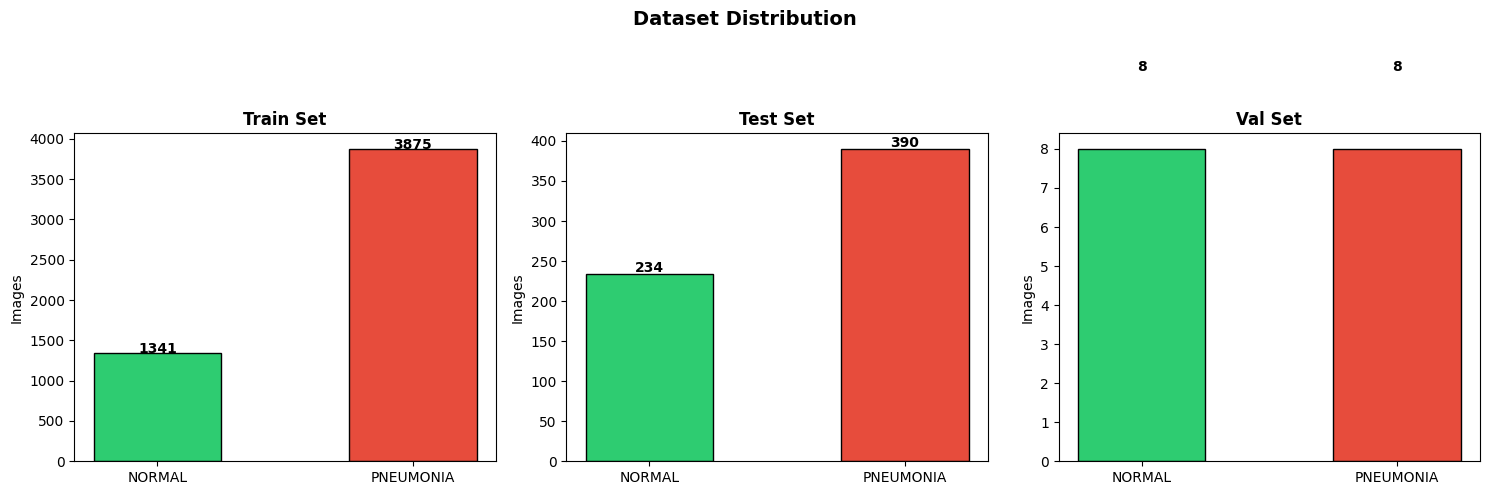

In [2]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dataset Distribution', fontsize=14, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']
for ax, (split, d) in zip(axes, splits.items()):
    counts = []
    for cls in ['NORMAL', 'PNEUMONIA']:
        p = os.path.join(d, cls)
        counts.append(len(os.listdir(p)) if os.path.exists(p) else 0)
    bars = ax.bar(['NORMAL', 'PNEUMONIA'], counts, color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{split} Set', fontweight='bold')
    ax.set_ylabel('Images')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/eda_distribution.png', dpi=150)
plt.show()

##  Insight

The dataset is imbalanced:
- Pneumonia cases are significantly higher than Normal cases
- This may bias the model toward predicting Pneumonia

 We need to handle class imbalance (Data Augmentation)

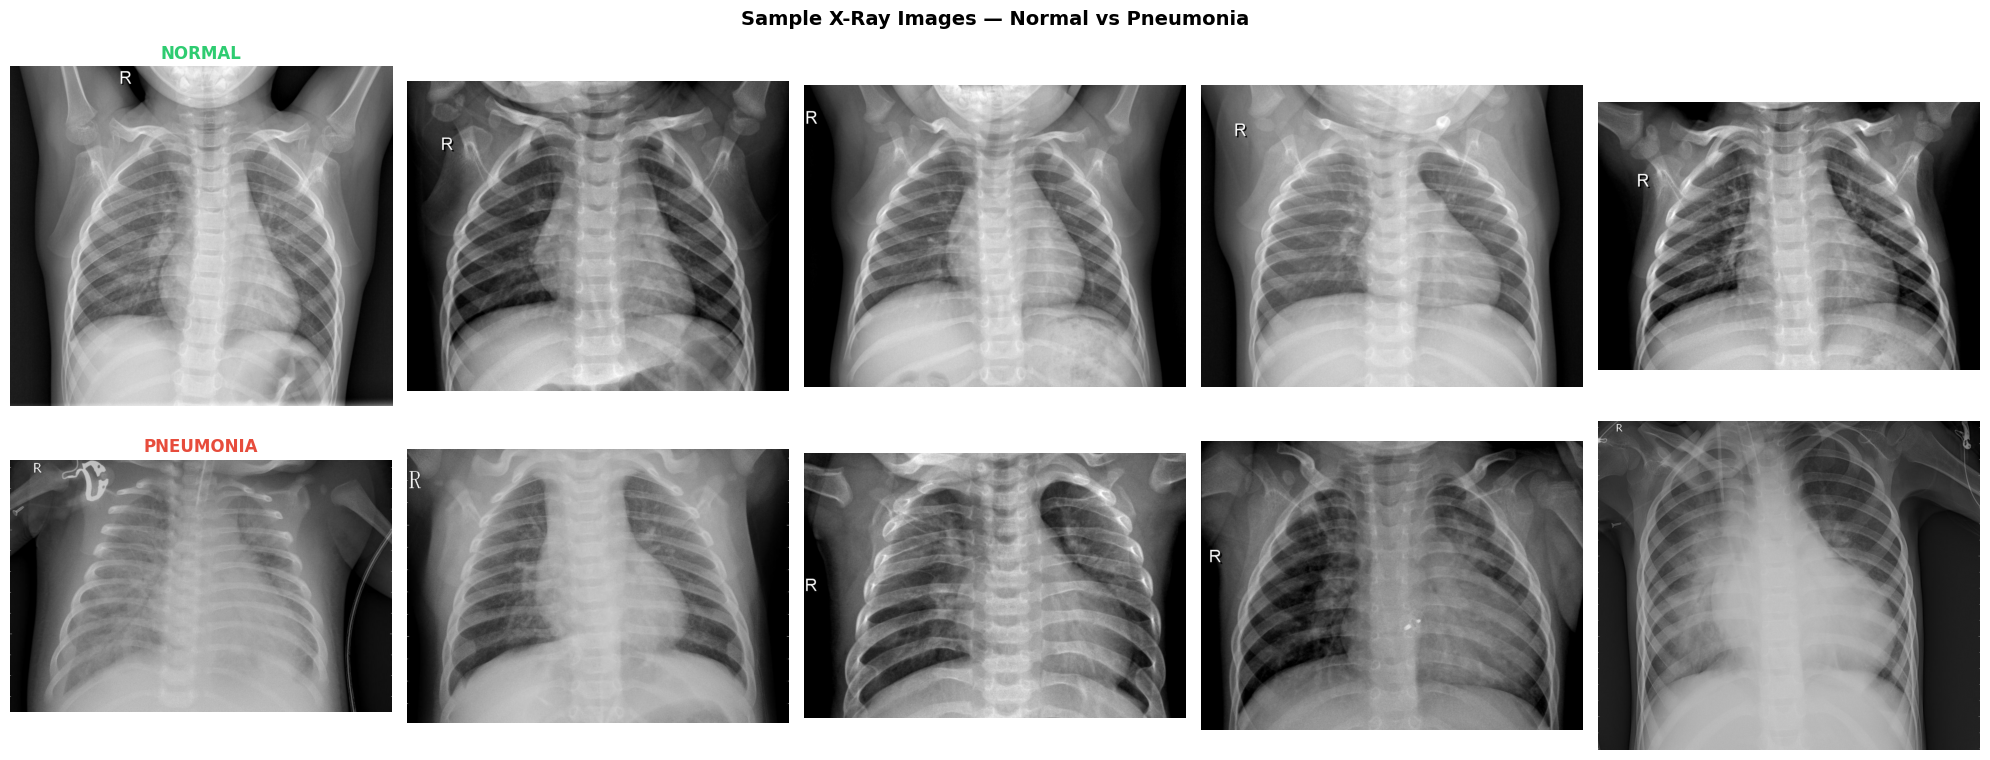

✅ EDA complete!


In [3]:
# Sample images grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sample X-Ray Images — Normal vs Pneumonia', fontsize=14, fontweight='bold')
for row, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    files = os.listdir(os.path.join(TRAIN_DIR, cls))[:5]
    color = '#2ecc71' if cls == 'NORMAL' else '#e74c3c'
    for col, fname in enumerate(files):
        img = cv2.imread(os.path.join(TRAIN_DIR, cls, fname), 0)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls if col == 0 else '', color=color, fontweight='bold')
        axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_samples.png', dpi=150)
plt.show()
print('✅ EDA complete!')

In [6]:
sizes = []

for cls in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(path)[:100]:  # sample
        img = cv2.imread(os.path.join(path, img_name))
        sizes.append(img.shape)

print("Sample sizes:", sizes[:5])

Sample sizes: [(1858, 2090, 3), (1152, 1422, 3), (1434, 1810, 3), (1279, 1618, 3), (1125, 1600, 3)]


##  Insight

- Image sizes are not consistent

 We must resize all images (224x224)

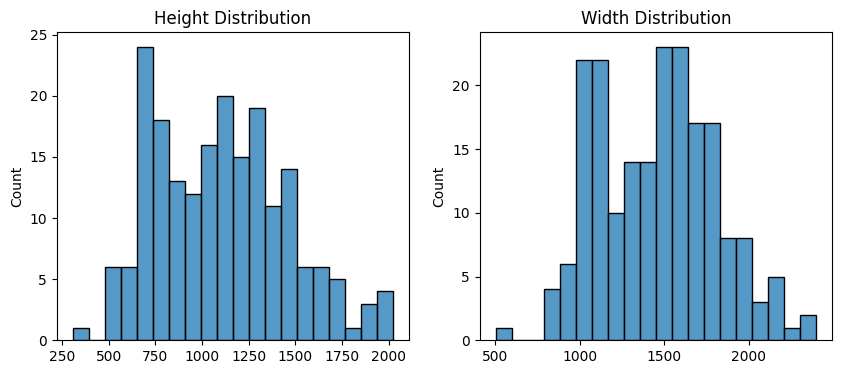

In [11]:
heights = [s[0] for s in sizes]
widths = [s[1] for s in sizes]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(heights, bins=20)
plt.title("Height Distribution")

plt.subplot(1,2,2)
sns.histplot(widths, bins=20)
plt.title("Width Distribution")

plt.show()

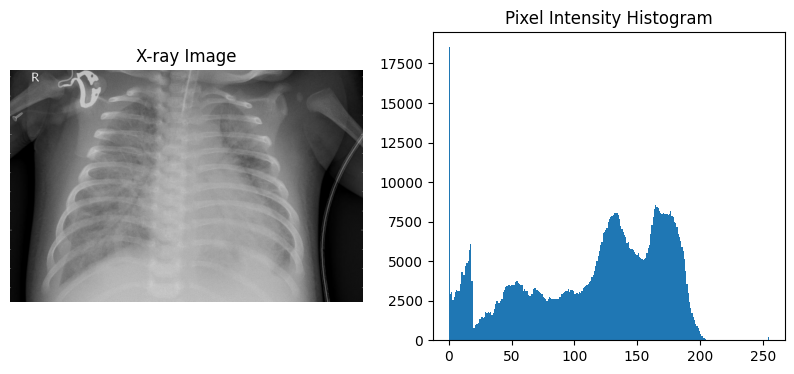

In [8]:
img_path = os.path.join(TRAIN_DIR, "PNEUMONIA", os.listdir(os.path.join(TRAIN_DIR, "PNEUMONIA"))[0])
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("X-ray Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(img.ravel(), bins=256)
plt.title("Pixel Intensity Histogram")

plt.show()

##  Insight

The pixel intensity values are concentrated within a narrow range,
resulting in low contrast images.

 This limits the visibility of important features in X-ray images.

To address this, CLAHE (Contrast Limited Adaptive Histogram Equalization)
will be applied to enhance contrast and improve feature visibility.

#  Final Summary

- Dataset is (balanced / imbalanced)
- Images vary in size → need resizing
- Contrast is limited → apply CLAHE
- Noise may exist → apply filtering